In [1]:
!git clone https://github.com/baturaysaglam/llm-subspaces.git

Cloning into 'llm-subspaces'...
remote: Enumerating objects: 6195, done.
remote: Counting objects: 100% (4744/4744), done.
remote: Compressing objects: 100% (3292/3292), done.
remote: Total 6195 (delta 1215), reused 4524 (delta 1008), pack-reused 1451 (from 2)
Receiving objects: 100% (6195/6195), 72.95 MiB | 12.60 MiB/s, done.
Resolving deltas: 100% (1320/1320), done.
Updating files: 100% (6053/6053), done.


In [ ]:
from huggingface_hub import login
login('') # hugging-face token
%cd /content/llm-subspaces

/content/llm-subspaces


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

def safe_tensor_load(file_path):
    """Tensor safe load for every dtype"""
    try:
        # cpu load
        tensor = torch.load(file_path, map_location='cpu')

        # float32 convertion if needed
        if tensor.dtype in [torch.bfloat16, torch.float16]:
            tensor = tensor.to(torch.float32)

        return tensor.numpy()
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def load_and_convert_tensor(file_path):
    """Tensor load  float32"""
    data = torch.load(file_path, map_location='cpu')
    if data.dtype == torch.bfloat16:
        data = data.to(torch.float32)
    return data.numpy()

In [ ]:
!python hidden_state.py --model "google/gemma-2b" --layers 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 --dataset arxiv --topic cs  --batch_size 4 --num_samples 1500 --max_tokens 128
!python hidden_state.py --model "google/gemma-2b" --layers 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 --dataset arxiv --topic eess  --batch_size 4 --num_samples 1500 --max_tokens 128
!python hidden_state.py --model "google/gemma-2b" --layers 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 --dataset arxiv --topic math  --batch_size 4 --num_samples 1500 --max_tokens 128
!python hidden_state.py --model "google/gemma-2b" --layers 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 --dataset arxiv --topic physics  --batch_size 4 --num_samples 1500 --max_tokens 128
!python hidden_state.py --model "google/gemma-2b" --layers 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 --dataset arxiv --topic q-bio  --batch_size 4 --num_samples 1500 --max_tokens 128
!python hidden_state.py --model "google/gemma-2b" --layers 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 --dataset arxiv --topic stat  --batch_size 4 --num_samples 1500 --max_tokens 128

config.json: 100% 627/627 [00:00<00:00, 4.68MB/s]
`torch_dtype` is deprecated! Use `dtype` instead!
2025-12-13 10:57:50.930314: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765623470.947280    1533 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765623470.952240    1533 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765623470.965752    1533 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765623470.965775    1533 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target mor

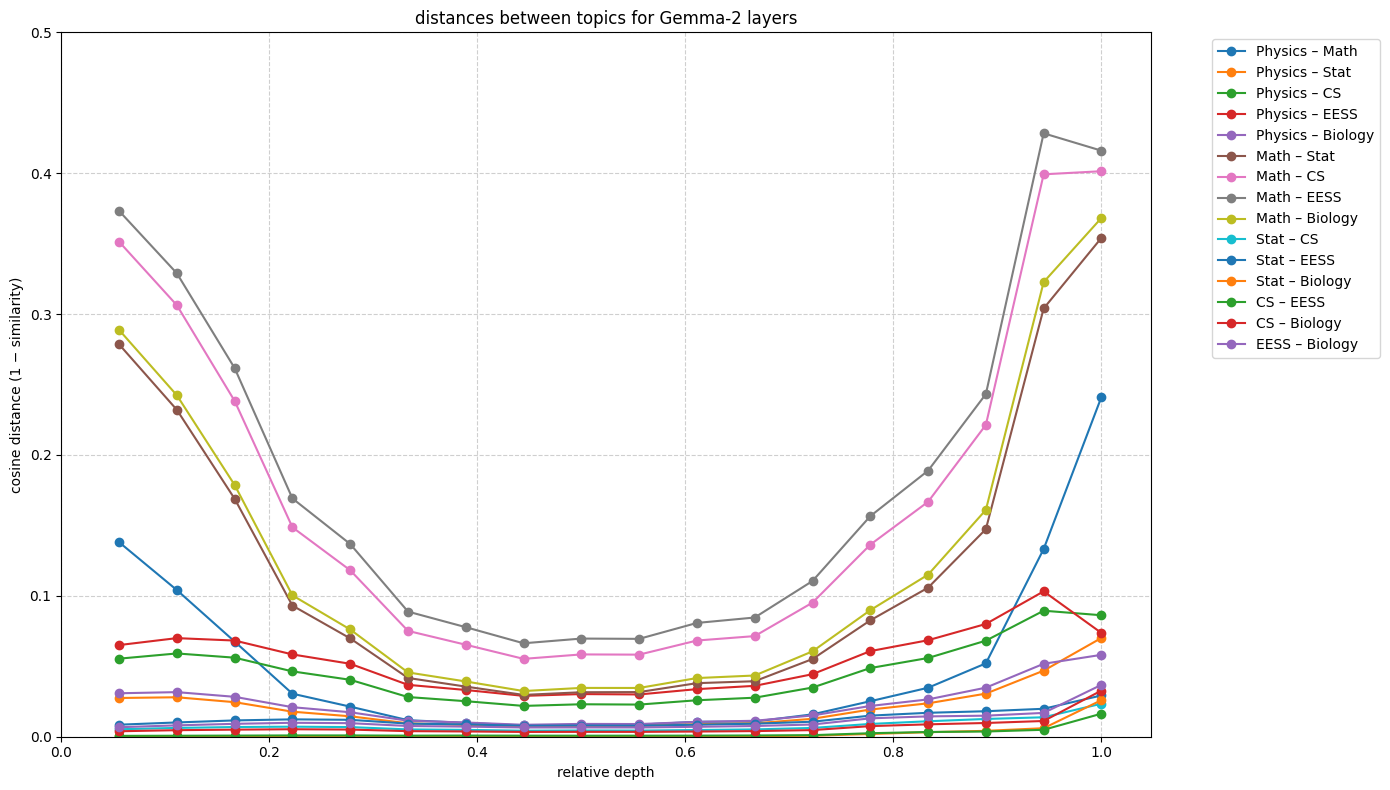

In [ ]:
from itertools import combinations

def get_means_for_layer(physics_path, math_path, stat_path, cs_path, eess_path, qbio_path):
    paths = [physics_path, math_path, stat_path, cs_path, eess_path, qbio_path]
    all_data = []

    for path in paths:
        data_list = []
        for file in sorted(os.listdir(path)):
            if file.endswith('.pt'):
                data = load_and_convert_tensor(os.path.join(path, file))
                data_list.append(data)
        combined = np.concatenate(data_list, axis=0) if data_list else np.array([]).reshape(0, -1)
        all_data.append(combined)

    centroids = []
    for data in all_data:
        if data.size == 0:
            raise ValueError("No data for such topic")
        centroids.append(np.mean(data, axis=0))

    return centroids

def normalize(v):
    norm = np.linalg.norm(v)
    return v / norm if norm > 0 else v

def cosine_distance(x1, x2):
    x1_n = normalize(x1)
    x2_n = normalize(x2)
    sim = np.dot(x1_n, x2_n)
    sim = np.clip(sim, -1.0, 1.0)
    return 1.0 - sim

# topics
topic_names = ["physics", "math", "stat", "cs", "eess", "q-bio"]
topic_labels = ["Physics", "Math", "Stat", "CS", "EESS", "Biology"]

# Gemma2 layers: from 1 to 18
n_layers = 18
layer_indices = list(range(1, n_layers + 1))


# calcing centroids for each layer
all_centroids_per_layer = []

for layer in layer_indices:
    base_path = f"hidden_states/gemma-2b/layer_{layer}/arxiv/"
    paths = [os.path.join(base_path, t) for t in topic_names]
    centroids = get_means_for_layer(*paths)
    all_centroids_per_layer.append(centroids)

# calcing pair-wise cosine distance
pair_labels = []
pair_distances_per_layer = []  # [pair_idx][layer]

for i, j in combinations(range(len(topic_names)), 2):
    pair_labels.append(f"{topic_labels[i]} – {topic_labels[j]}")
    pair_distances_per_layer.append([])


for layer in layer_indices:
    centroids = all_centroids_per_layer[layer - 1]
    idx = 0
    for i, j in combinations(range(len(topic_names)), 2):
        dist = cosine_distance(centroids[i], centroids[j])
        pair_distances_per_layer[idx].append(dist)
        idx += 1

plt.figure(figsize=(14, 8))
for dists, label in zip(pair_distances_per_layer, pair_labels):
    plt.plot(np.array(layer_indices) / 18.0, dists, marker='o', label=label)

plt.title('distances between topics for Gemma-2 layers')
plt.xlabel('relative depth')
plt.ylabel('cosine distance (1 − similarity)')
plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.ylim(0, 0.5)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
!python hidden_state.py --model "openai-community/gpt2" --layers 1 2 3 4 5 6 7 8 9 10 11 12 --dataset arxiv --topic cs  --batch_size 4 --num_samples 1500 --max_tokens 128
!python hidden_state.py --model "openai-community/gpt2" --layers 1 2 3 4 5 6 7 8 9 10 11 12 --dataset arxiv --topic eess  --batch_size 4 --num_samples 1500 --max_tokens 128
!python hidden_state.py --model "openai-community/gpt2" --layers 1 2 3 4 5 6 7 8 9 10 11 12 --dataset arxiv --topic math  --batch_size 4 --num_samples 1500 --max_tokens 128
!python hidden_state.py --model "openai-community/gpt2" --layers 1 2 3 4 5 6 7 8 9 10 11 12 --dataset arxiv --topic physics  --batch_size 4 --num_samples 1500 --max_tokens 128
!python hidden_state.py --model "openai-community/gpt2" --layers 1 2 3 4 5 6 7 8 9 10 11 12 --dataset arxiv --topic q-bio  --batch_size 4 --num_samples 1500 --max_tokens 128
!python hidden_state.py --model "openai-community/gpt2" --layers 1 2 3 4 5 6 7 8 9 10 11 12 --dataset arxiv --topic stat  --batch_size 4 --num_samples 1500 --max_tokens 128

python3: can't open file '/content/hidden_state.py': [Errno 2] No such file or directory
python3: can't open file '/content/hidden_state.py': [Errno 2] No such file or directory
python3: can't open file '/content/hidden_state.py': [Errno 2] No such file or directory
python3: can't open file '/content/hidden_state.py': [Errno 2] No such file or directory
python3: can't open file '/content/hidden_state.py': [Errno 2] No such file or directory
python3: can't open file '/content/hidden_state.py': [Errno 2] No such file or directory


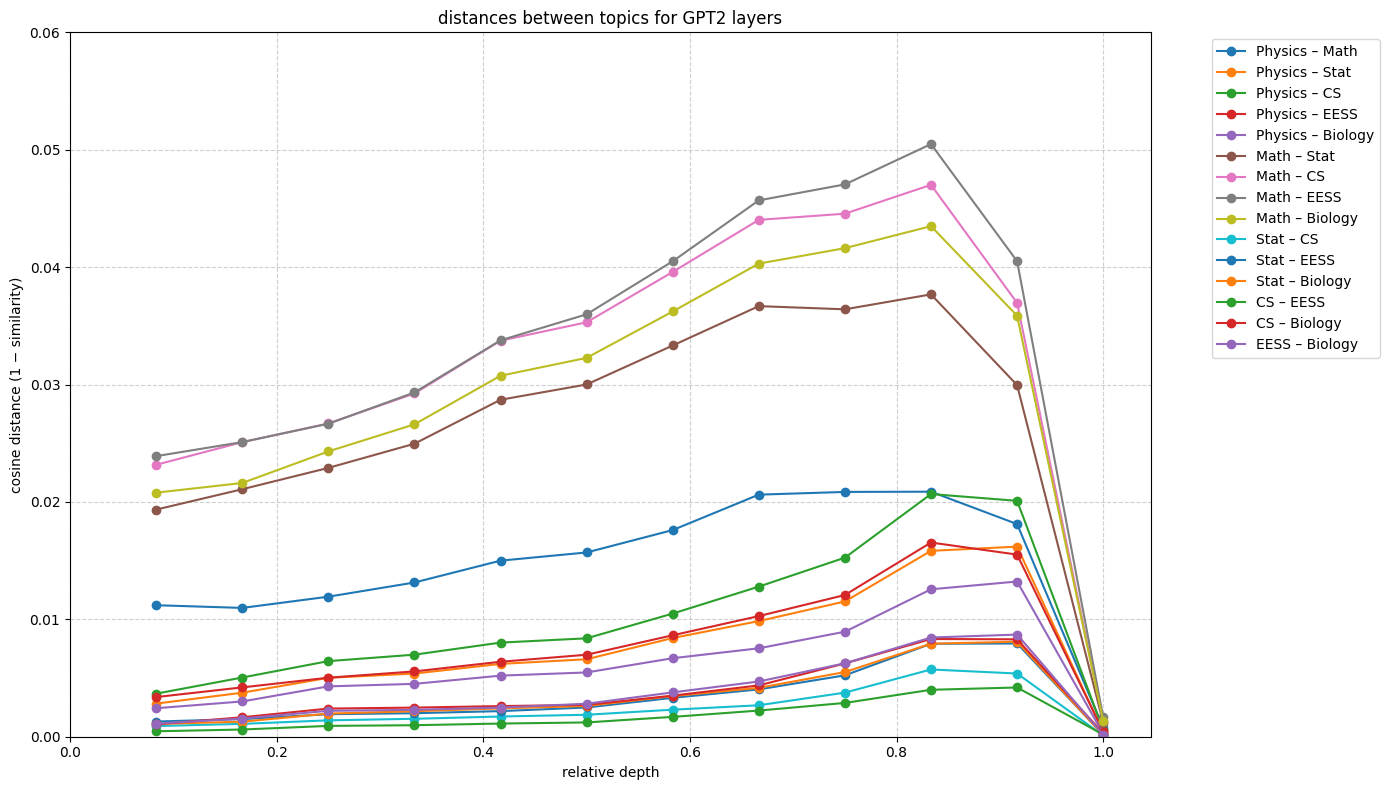

In [ ]:
from itertools import combinations

def get_means_for_layer(physics_path, math_path, stat_path, cs_path, eess_path, qbio_path):
    paths = [physics_path, math_path, stat_path, cs_path, eess_path, qbio_path]
    all_data = []

    for path in paths:
        data_list = []
        for file in sorted(os.listdir(path)):
            if file.endswith('.pt'):
                data = load_and_convert_tensor(os.path.join(path, file))
                data_list.append(data)
        combined = np.concatenate(data_list, axis=0) if data_list else np.array([]).reshape(0, -1)
        all_data.append(combined)

    centroids = []
    for data in all_data:
        if data.size == 0:
            raise ValueError("No data for such topic")
        centroids.append(np.mean(data, axis=0))

    return centroids

def normalize(v):
    norm = np.linalg.norm(v)
    return v / norm if norm > 0 else v

def cosine_distance(x1, x2):
    x1_n = normalize(x1)
    x2_n = normalize(x2)
    sim = np.dot(x1_n, x2_n)
    sim = np.clip(sim, -1.0, 1.0)
    return 1.0 - sim

# topics
topic_names = ["physics", "math", "stat", "cs", "eess", "q-bio"]
topic_labels = ["Physics", "Math", "Stat", "CS", "EESS", "Biology"]

# Gpt2 layers: from 1 to 12
n_layers = 12
layer_indices = list(range(1, n_layers + 1))


# calcing centroids for each layer
all_centroids_per_layer = []

for layer in layer_indices:
    base_path = f"hidden_states/gpt2/layer_{layer}/arxiv/"
    paths = [os.path.join(base_path, t) for t in topic_names]
    centroids = get_means_for_layer(*paths)
    all_centroids_per_layer.append(centroids)

# calcing pair-wise cosine distance
pair_labels = []
pair_distances_per_layer = []  # [pair_idx][layer]

for i, j in combinations(range(len(topic_names)), 2):
    pair_labels.append(f"{topic_labels[i]} – {topic_labels[j]}")
    pair_distances_per_layer.append([])


for layer in layer_indices:
    centroids = all_centroids_per_layer[layer - 1]
    idx = 0
    for i, j in combinations(range(len(topic_names)), 2):
        dist = cosine_distance(centroids[i], centroids[j])
        pair_distances_per_layer[idx].append(dist)
        idx += 1

plt.figure(figsize=(14, 8))
for dists, label in zip(pair_distances_per_layer, pair_labels):
    plt.plot(np.array(layer_indices) / 12.0, dists, marker='o', label=label)

plt.title('distances between topics for GPT2 layers')
plt.xlabel('relative depth')
plt.ylabel('cosine distance (1 − similarity)')
plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.ylim(0, 0.06)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()